In [18]:
from dataclasses import dataclass

import scanpy as sc
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import pickle
import shap
from scipy import stats
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [19]:
cell = 'complex'

def get_exp_name(cell):
    if cell == 'complex':
        return 'exp_complex'
    elif cell == 'defined':
        return 'exp_defined'
    else:
        raise ValueError(f"Unknown cell type {cell}")

train_data_path = f"/home/v-zhaoyang2/project/DNADesign/regLM/yeast_promoters/01_data_processing/motif_data/surrogate_{cell}_train_500000_sites.h5ad"
val_data_path = f"/home/v-zhaoyang2/project/DNADesign/regLM/yeast_promoters/01_data_processing/motif_data/surrogate_{cell}_val_500000_sites.h5ad"
test_data_path = f"/home/v-zhaoyang2/project/DNADesign/regLM/yeast_promoters/01_data_processing/motif_data/surrogate_{cell}_test_500000_sites.h5ad"

model_path = f"saved/model_{cell}_mbo_best.txt"


In [20]:
adata = sc.read(test_data_path)
X = adata.X
y = adata.obs[get_exp_name(cell)].values
print(f"shape of X: {X.shape}")
print(f"shape of y: {y.shape}")

feature_names = adata.var.index.tolist()
print(f"number of features: {len(feature_names)}")

shape of X: (23575, 140)
shape of y: (23575,)
number of features: 140


In [21]:
model = lgb.Booster(model_file=model_path)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

shap_values_matrix = shap_values.values
# adjusted_shap_values_matrix = shap_values_matrix * (X)
adjusted_shap_values_matrix = shap_values_matrix * (X != 0)

mean_shap_values = []
max_shap_values = []
min_shap_values = []

for i in range(len(feature_names)):
    non_zero_shap_values = adjusted_shap_values_matrix[X[:, i] > 0, i]
   
    if len(non_zero_shap_values) > 0:
        mean_shap = np.mean(non_zero_shap_values)
        max_shap = np.max(non_zero_shap_values)
        min_shap = np.min(non_zero_shap_values) 
    else:
        mean_shap = np.nan
        max_shap = np.nan
        min_shap = np.nan
        
    mean_shap_values.append(mean_shap)
    max_shap_values.append(max_shap)
    min_shap_values.append(min_shap)

In [22]:

t_stats, p_values = [], []
for i in range(len(feature_names)):
    non_zero_shap_values = adjusted_shap_values_matrix[X[:, i] > 0, i]
    

    if len(non_zero_shap_values) > 1: 
        t_stat, p_value = stats.ttest_1samp(non_zero_shap_values, 0)
    else:
        t_stat, p_value = np.nan, np.nan  
        
    t_stats.append(t_stat)
    p_values.append(p_value)

In [23]:

results_df = pd.DataFrame({
    'TFBS': feature_names,
    'Mean_SHAP': mean_shap_values,
    "Max_SHAP": max_shap_values,
    "Min_SHAP": min_shap_values,
    'T_stat': t_stats,
    'P_value': p_values
})


save_path = f"results_{cell}_mbo.csv"
results_df.to_csv(save_path, index=False)
print(f"Results saved to {save_path}")

significance_level = 0.05
significant_results = results_df[results_df['P_value'] < significance_level]


promoting_tfbs = significant_results[significant_results['Mean_SHAP'] > 0]
inhibiting_tfbs = significant_results[significant_results['Mean_SHAP'] < 0]

print("\nPromoting TFBS (Positive SHAP values):")
print(promoting_tfbs)

print("\nInhibiting TFBS (Negative SHAP values):")
print(inhibiting_tfbs)

Results saved to results_complex_mbo.csv

Promoting TFBS (Positive SHAP values):
               TFBS  Mean_SHAP  Max_SHAP  Min_SHAP      T_stat  P_value
0     MA0265.3.ABF1   0.445470  1.527378  0.027043  112.004444      0.0
4     MA0270.2.AFT2   0.321143  1.824082  0.063922  132.380280      0.0
5    MA0271.1.ARG80   0.098808  0.782503 -0.190334   57.015543      0.0
7    MA0273.2.ARO80   0.376125  1.399405  0.091870  135.019038      0.0
10    MA0276.1.ASH1   0.140569  0.628049 -0.036004  158.741294      0.0
..              ...        ...       ...       ...         ...      ...
128   MA0416.2.YAP3   0.029646  0.237425 -0.289255   44.796672      0.0
132   MA0420.2.ERT1   0.103180  0.590545 -0.078941   89.108595      0.0
133   MA0421.1.NSI1   0.065017  0.768953 -0.407784   66.289306      0.0
134   MA0422.2.URC2   0.262030  1.092818 -0.091545  107.206076      0.0
136   MA0431.2.TDA9   0.192484  1.095013 -0.199963   81.091121      0.0

[76 rows x 6 columns]

Inhibiting TFBS (Negative SHAP 

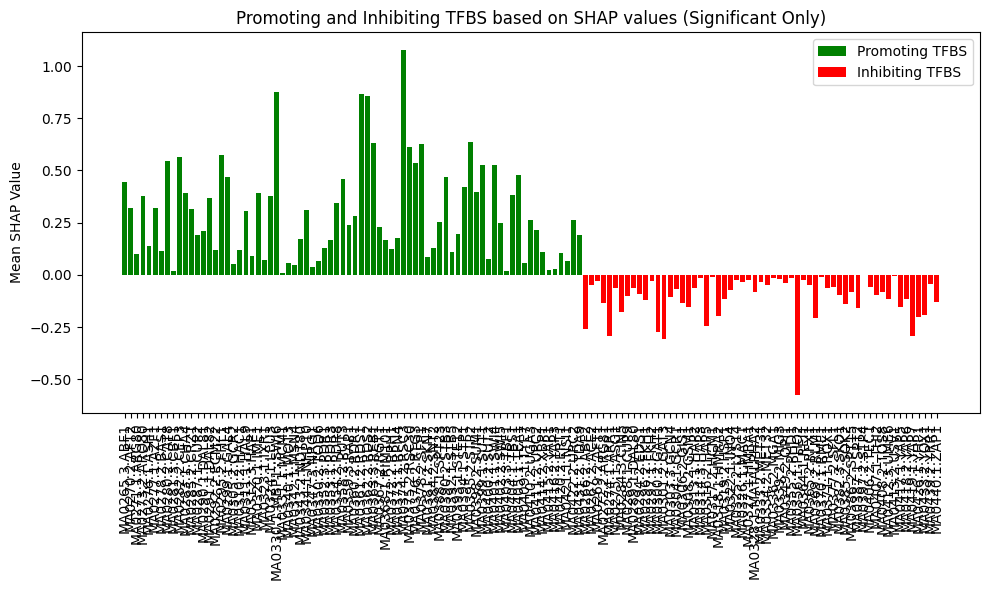

In [24]:
plt.figure(figsize=(10, 6))
if not promoting_tfbs.empty:
    plt.bar(promoting_tfbs['TFBS'], promoting_tfbs['Mean_SHAP'], color='green', label='Promoting TFBS')
if not inhibiting_tfbs.empty:
    plt.bar(inhibiting_tfbs['TFBS'], inhibiting_tfbs['Mean_SHAP'], color='red', label='Inhibiting TFBS')

plt.xticks(rotation=90)
plt.ylabel('Mean SHAP Value')
plt.title('Promoting and Inhibiting TFBS based on SHAP values (Significant Only)')
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
import json


result_dict = {}
for index, row in results_df.iterrows():
    if row['P_value'] < significance_level:
        result_dict[row['TFBS']] = row['Mean_SHAP']
    else:
        result_dict[row['TFBS']] = 0  

output_path = f"results_{cell}_mbo.json"
with open(output_path, 'w') as json_file:
    json.dump(result_dict, json_file, indent=4)

print(f"Results saved to {output_path}")

Results saved to results_complex_mbo.json
